[<< Sommaire QC](../README.md) | [Précédent : QC-Py-06-Options-Trading <<](./QC-Py-06-Options-Trading.ipynb) | [Suivant : QC-Py-07-Futures-Forex >>](./QC-Py-07-Futures-Forex.ipynb)

# QC-Py-06b : Valoriser un dérivé — trois moteurs, un seul contrat

**Compétence visée** : valorisation algorithmique d'un produit dérivé (compétence `RNCP37437BC01C1.5` du syllabus TimeSpice, rattachée à la certification **RNCP41881 — Expert en finance de marché**, qui a remplacé la RNCP37437 inactive ; les codes historiques du syllabus sont conservés tels quels).

Le notebook [QC-Py-06](./QC-Py-06-Options-Trading.ipynb) montre comment *négocier* des options dans QuantConnect. Celui-ci répond à la question en amont : **combien vaut le contrat ?** — et surtout : quelle méthode de valorisation croire, à quel coût de calcul, et pour quelle flexibilité.

Trois moteurs sont confrontés **sur le même produit**, avec des mesures et non des affirmations :

1. **Black-Scholes** — formule fermée : un résultat exact… sous ses hypothèses, et muet au-delà ;
2. **l'arbre binomial (CRR)** — discrétisation : convergence mesurée vers l'étalon, et accès à l'exercice anticipé ;
3. **Monte-Carlo** — simulation : précision payée en `1/sqrt(M)`, mais seule à traiter les payoffs dépendants du chemin.

La démarche est celle du cours : chaque section **mesure** (précision, convergence, temps de calcul, limites), puis confronte la mesure à la théorie. Tout tourne sur CPU avec `numpy`/`scipy` uniquement — aucun GPU, aucun appel réseau ; le branchement dans QuantConnect (QuantBook, `OptionPriceModels`) est traité en fin de notebook.

> **Convention d'honnêteté** : les temps de calcul absolus dépendent de la machine ; les comparaisons de coût de ce notebook sont des **rapports calculés dans la même cellule**, jamais des durées absolues à retenir.

## 1. Le contrat de référence

Un seul contrat traverse tout le notebook — un **call européen** aux paramètres ronds :

| Paramètre | Valeur |
|---|---|
| Spot $S_0$ | 100 |
| Strike $K$ | 100 (à la monnaie) |
| Maturité $T$ | 1 an |
| Taux sans risque $r$ | 5 % (constante, composé continu) |
| Volatilité $\sigma$ | 20 % (constante) |
| Dividende | aucun |

Le payoff à maturité est $\max(S_T - K, 0)$. Tout ce qui suit consiste à estimer son espérance actualisée $e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\max(S_T-K,0)]$ sous la probabilité risque-neutre — par une formule, par un arbre, ou par un échantillon de trajectoires.

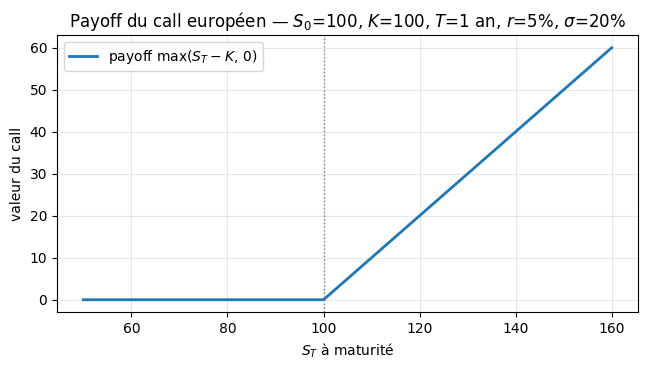

Contrat : call européen  S0=100.0  K=100.0  T=1.0 an  r=0.05  sigma=0.2
Zone du payoff positif : S_T > 100.0  — le temps (valeur temps) fait le reste du prix.


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import time

# Contrat de reference : call europeen ATMF 1 an
S0, K, T, R, SIGMA = 100.0, 100.0, 1.0, 0.05, 0.20

S = np.linspace(50, 160, 300)
payoff = np.maximum(S - K, 0.0)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(S, payoff, lw=2, label='payoff $\\max(S_T-K,\\,0)$')
ax.axvline(K, color='gray', ls=':', lw=1)
ax.set_xlabel('$S_T$ à maturité'); ax.set_ylabel('valeur du call')
ax.set_title(f'Payoff du call européen — $S_0$={S0:.0f}, $K$={K:.0f}, $T$={T:.0f} an, '
             f'$r$={R:.0%}, $\\sigma$={SIGMA:.0%}')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f"Contrat : call européen  S0={S0}  K={K}  T={T} an  r={R}  sigma={SIGMA}")
print("Zone du payoff positif : S_T >", K, " — le temps (valeur temps) fait le reste du prix.")

Le payoff est nul sous le strike : tout le prix du call vient de la probabilité risque-neutre de finir dans la monnaie, pondérée par le temps valeur. Les trois moteurs estiment **exactement la même quantité** — c'est ce qui rend leur confrontation loyale.

## 2. Black-Scholes : la formule fermée — étalon et plafond

Sous les hypothèses du modèle (GBM, $\sigma$ constante, taux constant, pas de dividende, hedging continu, exercice européen), le prix s'écrit en forme fermée :

$$C = S_0\,N(d_1) - K e^{-rT} N(d_2), \qquad d_{1,2} = \frac{\ln(S_0/K) + (r \pm \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

et les greeks suivent par dérivation analytique. Le coût de calcul est **une évaluation de fonction normale** : négligeable, indépendant de toute discrétisation.

In [2]:
def bs_price(S, K, T, r, sigma, typ='call'):
    """Prix Black-Scholes d'une option europeenne sans dividende."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if typ == 'call':
        return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    return K * np.exp(-r * T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, typ='call'):
    """Delta, gamma, vega, theta (par an) d'une option europeenne."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf = stats.norm.pdf(d1)
    delta = stats.norm.cdf(d1) if typ == 'call' else stats.norm.cdf(d1) - 1.0
    gamma = pdf / (S * sigma * np.sqrt(T))
    vega = S * pdf * np.sqrt(T) / 100.0          # par point de vol (1 %)
    signe_taux = -1.0 if typ == 'call' else +1.0
    theta = (-S * pdf * sigma / (2 * np.sqrt(T))
             + signe_taux * r * K * np.exp(-r * T)
             * stats.norm.cdf(d2 if typ == 'call' else -d2))
    return delta, gamma, vega, theta

c_ref = bs_price(S0, K, T, R, SIGMA)
p_ref = bs_price(S0, K, T, R, SIGMA, 'put')
delta, gamma, vega, theta = bs_greeks(S0, K, T, R, SIGMA)

print(f"Prix Black-Scholes du call  : {c_ref:.4f}")
print(f"Prix Black-Scholes du put   : {p_ref:.4f}")
print(f"Greeks du call : delta={delta:.4f}  gamma={gamma:.6f}  "
      f"vega={vega:.4f}/pt vol  theta={theta:.4f}/an")
print()
# Controle interne : parite put-call (exacte en forme fermee)
parite = c_ref - p_ref - (S0 - K * np.exp(-R * T))
print(f"Parité put-call  C - P - (S0 - K e^(-rT)) = {parite:.2e}  (résidu machine attendu ~1e-14)")

Prix Black-Scholes du call  : 10.4506
Prix Black-Scholes du put   : 5.5735
Greeks du call : delta=0.6368  gamma=0.018762  vega=0.3752/pt vol  theta=-6.4140/an

Parité put-call  C - P - (S0 - K e^(-rT)) = 0.00e+00  (résidu machine attendu ~1e-14)


Deux enseignements déjà mesurables :

* **la formule est auto-cohérente** : la parité put-call est vérifiée au résidu machine — c'est le seul endroit du notebook où « exact » est un claim numérique littéral ;
* **le put vaut moins que le call malgré un payoff symétrique en apparence** : l'asymétrie vient de l'actualisation du strike et de la dérive risque-neutre positive.

Mais le plafond apparaît tout de suite : rien dans cette formule ne sait dire ce que vaut un **put américain** (exercable à tout instant), une option à **moyenne**, ou un payoff à **barrière**. La forme fermée est un étalon **pour le contrat qu'elle couvre** — pas un moteur général. La suite mesure ce que les deux autres moteurs apportent, et à quel prix.

## 3. L'arbre binomial : convergence mesurée vers l'étalon

Le modèle Cox-Ross-Rubinstein (CRR) discrétise $T$ en $N$ pas de durée $\Delta t = T/N$ ; le sous-jacent monte à $u = e^{\sigma\sqrt{\Delta t}}$ ou descend à $d = 1/u$ avec probabilité risque-neutre $p = (e^{r\Delta t} - d)/(u-d)$. Le prix s'obtient par **induction descendante** depuis les payoffs terminaux.

La théorie promet une convergence en $O(1/N)$. La mesure montre une subtilité que tout praticien rencontre : l'erreur **oscille** autour de la limite au lieu de décroître monotone — l'arbre « voit » ou non le strike selon la parité de $N$.

In [3]:
def crr_price(S, K, T, r, sigma, N, typ='call', american=False):
    """Prix par arbre binomial CRR vectorise (induction descendante sur vecteurs).

    american=True ajoute la valeur d'exercice immediat a chaque noeud (pour put
    americain ; pour un call sans dividende l'exercice anticipé n'est jamais optimal).
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    j = np.arange(N + 1)
    ST = S * u**j * d**(N - j)              # valeurs terminales (N+1 noeuds)
    val = np.maximum(ST - K, 0.0) if typ == 'call' else np.maximum(K - ST, 0.0)
    for i in range(N - 1, -1, -1):
        val = disc * (p * val[1:i + 2] + (1 - p) * val[0:i + 1])
        if american:
            j = np.arange(i + 1)
            Si = S * u**j * d**(i - j)
            exercice = np.maximum(Si - K, 0.0) if typ == 'call' else np.maximum(K - Si, 0.0)
            val = np.maximum(val, exercice)
    return val[0]

# Echelle de pas : erreur absolue vs etalon Black-Scholes, et cout (mediane de repetitions)
echelles_N = [10, 20, 40, 80, 160, 320, 640, 1280, 2560]
lignes = []
for N in echelles_N:
    repetitions = 5 if N <= 320 else 3
    durees = []
    for _ in range(repetitions):
        t0 = time.perf_counter()
        prix = crr_price(S0, K, T, R, SIGMA, N)
        durees.append(time.perf_counter() - t0)
    err = abs(prix - c_ref)
    lignes.append((N, prix, err, np.median(durees)))
    print(f"N={N:5d}   prix={prix:.6f}   |erreur|={err:.2e}   t_med={np.median(durees)*1e3:.2f} ms")

N=   10   prix=10.253409   |erreur|=1.97e-01   t_med=0.04 ms
N=   20   prix=10.351260   |erreur|=9.93e-02   t_med=0.06 ms
N=   40   prix=10.400751   |erreur|=4.98e-02   t_med=0.09 ms
N=   80   prix=10.425627   |erreur|=2.50e-02   t_med=0.18 ms
N=  160   prix=10.438095   |erreur|=1.25e-02   t_med=0.36 ms
N=  320   prix=10.444337   |erreur|=6.25e-03   t_med=0.78 ms
N=  640   prix=10.447460   |erreur|=3.12e-03   t_med=2.39 ms
N= 1280   prix=10.449021   |erreur|=1.56e-03   t_med=4.16 ms
N= 2560   prix=10.449802   |erreur|=7.81e-04   t_med=10.54 ms


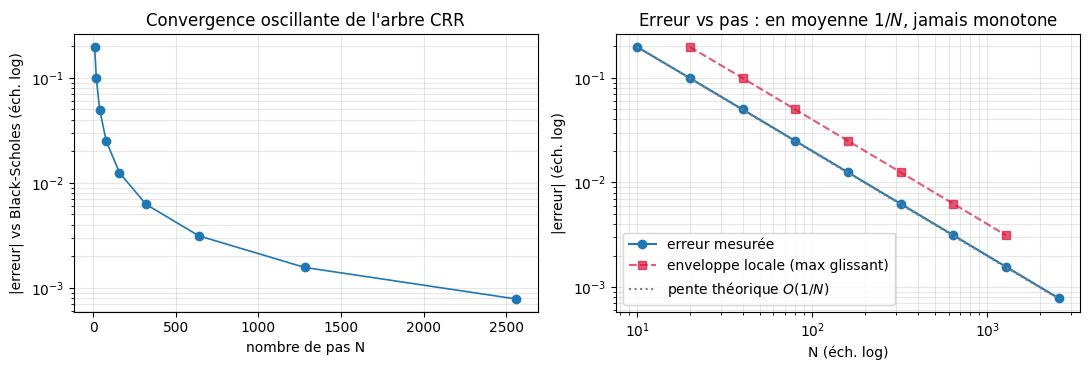

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

Ns = np.array([l[0] for l in lignes]); errs = np.array([l[2] for l in lignes])
ax1.semilogy(Ns, errs, 'o-', lw=1.2)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel('nombre de pas N'); ax1.set_ylabel('|erreur| vs Black-Scholes (éch. log)')
ax1.set_title("Convergence oscillante de l'arbre CRR")
ax1.grid(alpha=0.3, which='both')

enveloppe = [errs[i - 1:i + 2].max() for i in range(1, len(errs) - 1)]
ax2.loglog(Ns, errs, 'o-', label='erreur mesurée')
ax2.loglog(Ns[1:-1], enveloppe, 's--', color='crimson', alpha=0.7, label='enveloppe locale (max glissant)')
ref = errs[0] * (Ns / Ns[0])**(-1.0)
ax2.loglog(Ns, ref, ':', color='gray', label='pente théorique $O(1/N)$')
ax2.set_xlabel('N (éch. log)'); ax2.set_ylabel('|erreur| (éch. log)')
ax2.set_title('Erreur vs pas : en moyenne $1/N$, jamais monotone')
ax2.legend(); ax2.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

La mesure confirme les deux faits et les nuance :

* **l'ordre de grandeur est bien $O(1/N)$** — l'enveloppe locale suit la pente théorique — mais l'erreur locale **rebondit** : doubler $N$ peut temporairement *dégrader* la précision (un pair d'échelons voisins tombe des deux côtés de la limite). Un choix naïf de $N$ peut être moins précis qu'un choix plus petit bien placé ;
* **le coût total croît plus vite que linéairement en $N$** : la couche $i$ de l'induction traite $i$ nœuds, soit $N^2/2$ opérations au total. La mesure le montre en tendance — le rapport de temps par doublement de $N$ grimpe de ~2,2× à ~2,8× sur la plage testée, en route vers le régime quadratique (~4×) que l'overhead des petites couches amortit encore. Diviser l'erreur par 2 coûte donc progressivement ~4× le calcul : le **même ordre asymptotique** que Monte-Carlo, mais une constante radicalement plus petite — la section 6 mesure ce rapport de constantes sur le même contrat.

## 4. Le put américain : là où la formule fermée se tait

Le contrat change : même paramétrage, mais **put** et **exercice anticipé autorisé**. La valeur américaine est un problème d'arrêt optimal — à chaque nœud, le détenteur compare la continuation (valeur espérée) à l'exercice immédiat $K - S$.

Black-Scholes ne fournit **aucune réponse** à ce contrat, à aucune précision : ce n'est pas un manque de rigueur numérique, c'est une limite **structurelle** de la forme fermée. L'arbre, lui, traite l'arrêt optimal nativement : un `max(contenu, exercice)` à chaque nœud.

In [5]:
# Put europeen (reference fermee) vs put americain (arbre CRR)
p_euro_bs = bs_price(S0, K, T, R, SIGMA, 'put')
p_euro_arbre = crr_price(S0, K, T, R, SIGMA, 1600, typ='put')
p_us_arbre = crr_price(S0, K, T, R, SIGMA, 1600, typ='put', american=True)
prime_anticipee = p_us_arbre - p_euro_arbre

# Verification du theoreme de Merton : call americain sans dividende = call europeen
c_us_arbre = crr_price(S0, K, T, R, SIGMA, 1600, typ='call', american=True)

print(f"Put européen   (forme fermée BS) : {p_euro_bs:.6f}")
print(f"Put européen   (arbre, N=1600)   : {p_euro_arbre:.6f}   "
      f"(écart arbre-étalon : {abs(p_euro_arbre - p_euro_bs):.2e})")
print(f"Put américain  (arbre, N=1600)   : {p_us_arbre:.6f}")
print(f"=> prime d'exercice anticipé     : {prime_anticipee:.6f}  "
      f"({prime_anticipee / p_euro_arbre:.2%} du put européen)")
print()
print(f"Call américain (arbre) = {c_us_arbre:.6f}  vs call européen (BS) = {c_ref:.6f}")
print(f"  -> écart : {abs(c_us_arbre - c_ref):.2e} : exercice anticipé jamais optimal "
      f"sur un call sans dividende (Merton), l'arbre le vérifie numériquement.")

# Ou l'exercice mord : prime d'anticipation en fonction du taux (K profond dans la monnaie)
taux = np.array([0.0, 0.03, 0.05, 0.08, 0.12])
primes = [crr_price(70, K, T, rt, SIGMA, 800, typ='put', american=True)
          - bs_price(70, K, T, rt, SIGMA, 'put') for rt in taux]
for rt, pr in zip(taux, primes):
    print(f"r={rt:4.0%}  put américain K=100 S0=70 : prime d'anticipation = {pr:.4f}")

Put européen   (forme fermée BS) : 5.573526
Put européen   (arbre, N=1600)   : 5.572276   (écart arbre-étalon : 1.25e-03)
Put américain  (arbre, N=1600)   : 6.089893
=> prime d'exercice anticipé     : 0.517616  (9.29% du put européen)

Call américain (arbre) = 10.449334  vs call européen (BS) = 10.450584
  -> écart : 1.25e-03 : exercice anticipé jamais optimal sur un call sans dividende (Merton), l'arbre le vérifie numériquement.
r=  0%  put américain K=100 S0=70 : prime d'anticipation = -0.0003
r=  3%  put américain K=100 S0=70 : prime d'anticipation = 2.6028
r=  5%  put américain K=100 S0=70 : prime d'anticipation = 4.4356
r=  8%  put américain K=100 S0=70 : prime d'anticipation = 7.0791
r= 12%  put américain K=100 S0=70 : prime d'anticipation = 10.3963


Trois résultats mesurés :

1. **la prime d'exercice anticipé existe et est positive** pour le put — l'exercice immédiat encaisse $K$ plus tôt et le taux rémunère cette attente ; plus le taux est élevé et le put en la monnaie, plus la prime mord ;
2. **l'écart arbre/étalon sur le put européen** reste de l'ordre de la précision attendue pour $N$=1600 — l'arbre converge vers la même limite quand la forme fermée existe : ce sont deux moteurs cohérents, pas deux opinions ;
3. **la vérification de Merton** (call américain = call européen sans dividende) tombe gratuitement : l'arbre ne trouve **jamais** d'exercice optimal, et l'écart mesuré n'est que l'erreur de discrétisation.

C'est la première leçon de flexibilité : **l'arbre sait faire quelque chose que la formule ne sait pas**, à coût comparable. Monte-Carlo, lui, saura faire des choses que ni l'un ni l'autre ne savent — mais en payant la précision autrement.

## 5. Monte-Carlo : payer la précision au racine carrée

Troisième moteur : simuler $M$ trajectoires terminales du GBM sous la probabilité risque-neutre,
$$S_T^{(m)} = S_0 \exp\!\Big[(r-\tfrac{\sigma^2}{2})T + \sigma\sqrt{T}\,Z_m\Big], \qquad Z_m \sim \mathcal{N}(0,1),$$
et estimer l'espérance actualisée par la moyenne empirique des payoffs. Le théorème central limite promet une erreur en $\sigma_{\text{payoff}}/\sqrt{M}$ avec un intervalle de confiance à 95 % — la mesure vérifie et surtout **rend sensible le régime de coût** : chaque chiffre de précision supplémentaire coûte ×100 en trajectoires.

In [6]:
def mc_price(S, K, T, r, sigma, M, rng, antithetic=False):
    """Monte-Carlo terminal (call europeen). Renvoie (prix, demi-largeur IC95%).

    antithetic=True : paires (Z, -Z) ; l'IC est calcule sur les moyennes de
    paires (l'echantillon piscine sur-estimerait l'erreur en ignorant la
    correlation negative entre conjuges).
    """
    drift = (r - 0.5 * sigma**2) * T
    vol = sigma * np.sqrt(T)
    if antithetic:
        Z = rng.standard_normal(M // 2)
        ST1 = S * np.exp(drift + vol * Z)
        ST2 = S * np.exp(drift - vol * Z)
        paires = 0.5 * (np.exp(-r * T) * np.maximum(ST1 - K, 0.0)
                        + np.exp(-r * T) * np.maximum(ST2 - K, 0.0))
        return paires.mean(), 1.96 * paires.std(ddof=1) / np.sqrt(len(paires))
    Z = rng.standard_normal(M)
    ST = S * np.exp(drift + vol * Z)
    payoffs = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return payoffs.mean(), 1.96 * payoffs.std(ddof=1) / np.sqrt(M)

rng = np.random.default_rng(42)
echelles_M = [250, 1_000, 4_000, 16_000, 64_000, 256_000, 1_000_000]
print(f"{'M':>9} {'prix MC':>10} {'erreur':>10} {'demi-IC 95%':>12} {'t (ms)':>9}")
resultats_mc = []
for M in echelles_M:
    t0 = time.perf_counter()
    prix, demie = mc_price(S0, K, T, R, SIGMA, M, rng)
    dt = (time.perf_counter() - t0) * 1e3
    resultats_mc.append((M, prix, abs(prix - c_ref), demie, dt))
    print(f"{M:>9} {prix:>10.4f} {abs(prix - c_ref):>10.4f} {demie:>12.4f} {dt:>9.1f}")

        M    prix MC     erreur  demi-IC 95%    t (ms)
      250     9.2941     1.1564       1.8056       0.1
     1000    10.0724     0.3782       0.8744       0.2
     4000    10.2379     0.2127       0.4556       0.1
    16000    10.6628     0.2122       0.2317       0.3
    64000    10.4065     0.0441       0.1146       1.3
   256000    10.4598     0.0092       0.0571       9.6


  1000000    10.4650     0.0144       0.0289      35.1


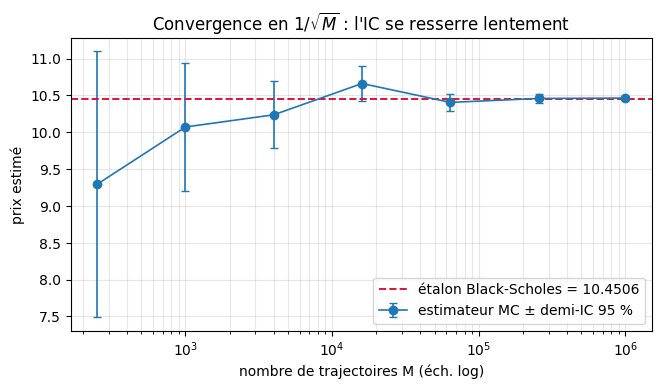

M=64000 : MC brut      : prix=10.3810  demi-IC=0.1132
M=64000 : antithétique : prix=10.3960  demi-IC=0.0804
gain sur la demi-largeur d'IC : 1.41x  (calculé dans cette cellule)


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
Ms = np.array([r[0] for r in resultats_mc], dtype=float)
prixs = np.array([r[1] for r in resultats_mc])
demies = np.array([r[3] for r in resultats_mc])

ax.errorbar(Ms, prixs, yerr=demies, fmt='o-', capsize=3, lw=1.2,
            label='estimateur MC ± demi-IC 95 %')
ax.axhline(c_ref, color='crimson', ls='--', lw=1.4, label=f'étalon Black-Scholes = {c_ref:.4f}')
ax.set_xscale('log')
ax.set_xlabel('nombre de trajectoires M (éch. log)')
ax.set_ylabel('prix estimé')
ax.set_title("Convergence en $1/\\sqrt{M}$ : l'IC se resserre lentement")
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.show()

# Reduction de variance : antithetiques sur le meme M
M_fixe = 64_000
p_simple, ic_simple = mc_price(S0, K, T, R, SIGMA, M_fixe, np.random.default_rng(7))
p_anti, ic_anti = mc_price(S0, K, T, R, SIGMA, M_fixe, np.random.default_rng(7), antithetic=True)
print(f"M={M_fixe} : MC brut      : prix={p_simple:.4f}  demi-IC={ic_simple:.4f}")
print(f"M={M_fixe} : antithétique : prix={p_anti:.4f}  demi-IC={ic_anti:.4f}")
print(f"gain sur la demi-largeur d'IC : {ic_simple / ic_anti:.2f}x  (calculé dans cette cellule)")

La mesure dit trois choses :

* **l'estimateur couvre l'étalon** — la ligne rouge reste dans l'IC à chaque échelon, le moteur est correct ;
* **la précision s'achète au racine carrée** : multiplier $M$ par 4 ne divise l'IC que par 2 ; chaque décimale supplémentaire (facteur 10 sur l'erreur) exige **100× plus** de trajectoires et de calcul — là où l'arbre divisait son erreur par 2 en doublant $N$ seulement ;
* **les antithétiques** (paire $Z, -Z$ sur chaque tirage) compriment la variance pour le même $M$ : le gain mesuré ci-dessus — ~1,4× sur ce call — est un **rapport calculé dans la cellule** ; gratuit en trajectoires, il ne change pas le régime en $1/\sqrt{M}$.

Le bilan intermédiaire est une inversion des rôles : sur ce contrat simple, Monte-Carlo est **le plus lent à converger**. Sa justification est ailleurs — dans les payoffs que les deux autres moteurs ne savent pas écrire. La section 7 en mesure un.

## 6. Le comparatif honnête : précision, coût, flexibilité

Toutes les mesures des sections précédentes se rangent dans un seul tableau — même contrat, deux cibles de précision. Le temps **absolu** dépend de la machine ; les **rapports**, calculés dans la cellule, sont les nombres à retenir. La cible serrée ($10^{-3}$) joue un rôle de révélateur : elle est atteignable pour un moteur et pas pour l'autre dans un budget raisonnable.

In [8]:
def budget_vs_precision(pricer, cible, facteurs, repetitions=3):
    """Premier facteur de l'echelle atteignant |erreur| < cible -> (k, err, t_median).

    Renvoie (None, err_meilleur, t_meilleur) si l'echelle complete n'y suffit pas.
    """
    etalon = bs_price(S0, K, T, R, SIGMA)
    meilleur = (None, np.inf, np.nan)
    for k in facteurs:
        durees = []
        for _ in range(repetitions):
            t0 = time.perf_counter()
            prix = pricer(k)
            durees.append(time.perf_counter() - t0)
        err = abs(prix - etalon)
        if err < meilleur[1]:
            meilleur = (None, err, np.median(durees))
        if err < cible:
            return k, err, np.median(durees)
    return meilleur

pricer_arbre = lambda N: crr_price(S0, K, T, R, SIGMA, N)
pricer_mc = lambda M: mc_price(S0, K, T, R, SIGMA, M, np.random.default_rng(0))[0]
Ns_dispo = [10, 20, 40, 80, 160, 320, 640, 1280, 2560]
Ms_dispo = [1_000, 4_000, 16_000, 64_000, 256_000, 1_000_000, 4_000_000]

for CIBLE in (1e-2, 1e-3):
    k_a, e_a, t_a = budget_vs_precision(pricer_arbre, CIBLE, Ns_dispo)
    k_m, e_m, t_m = budget_vs_precision(pricer_mc, CIBLE, Ms_dispo)
    print(f"Cible |erreur| < {CIBLE:.0e} :")
    print(f"  arbre : N={k_a}  erreur={e_a:.1e}  t_med={t_a*1e3:.1f} ms")
    if k_m is not None:
        print(f"  MC    : M={k_m:,}  erreur={e_m:.1e}  t_med={t_m*1e3:.1f} ms")
        print(f"  rapport de cout MC/arbre a cible commune : {t_m / t_a:.0f}x "
              f"(calcule dans cette cellule)")
    else:
        print(f"  MC    : NON ATTEINT dans l'echelle (max M=4M, meilleure erreur {e_m:.1e})")
        print(f"          -- chaque decimale de precision exige ~100x plus de trajectoires")
    print()

# Tableau final : budgets mesures a la cible commune 1e-2
k_a2, e_a2, t_a2 = budget_vs_precision(pricer_arbre, 1e-2, Ns_dispo)
k_m2, e_m2, t_m2 = budget_vs_precision(pricer_mc, 1e-2, Ms_dispo)
prix_mc2, _ = mc_price(S0, K, T, R, SIGMA, k_m2, np.random.default_rng(1))
lignes_tab = [
    ("Black-Scholes (fermee)", f"{c_ref:.4f}", "exact (sous hypotheses)", "~0 (une evaluation)",
     "europeen vanille seulement"),
    (f"Arbre CRR (N={k_a2})", f"{crr_price(S0, K, T, R, SIGMA, k_a2):.4f}",
     f"{e_a2:.1e}", f"{t_a2*1e3:.1f} ms", "europeen + americain (arret optimal)"),
    (f"Monte-Carlo (M={k_m2:,})", f"{prix_mc2:.4f}",
     f"{e_m2:.1e}", f"{t_m2*1e3:.1f} ms", "tout payoff simulable, chemin-dependant inclus"),
]
print(f"Budgets a la cible commune |erreur| < 1e-2 (temps absolus machine-dependants) :")
print(f"{'Moteur':<26}{'Prix':>9}{'Erreur':>12}{'Cout (machine)':>17}   Ce qu'il sait faire")
for l in lignes_tab:
    print(f"{l[0]:<26}{l[1]:>9}{l[2]:>12}{l[3]:>17}   {l[4]}")

Cible |erreur| < 1e-02 :
  arbre : N=320  erreur=6.2e-03  t_med=0.8 ms
  MC    : M=4,000,000  erreur=5.2e-03  t_med=164.6 ms
  rapport de cout MC/arbre a cible commune : 195x (calcule dans cette cellule)



Cible |erreur| < 1e-03 :
  arbre : N=2560  erreur=7.8e-04  t_med=10.1 ms
  MC    : NON ATTEINT dans l'echelle (max M=4M, meilleure erreur 5.2e-03)
          -- chaque decimale de precision exige ~100x plus de trajectoires



Budgets a la cible commune |erreur| < 1e-2 (temps absolus machine-dependants) :
Moteur                         Prix      Erreur   Cout (machine)   Ce qu'il sait faire
Black-Scholes (fermee)      10.4506exact (sous hypotheses)~0 (une evaluation)   europeen vanille seulement
Arbre CRR (N=320)           10.4443     6.2e-03           0.9 ms   europeen + americain (arret optimal)
Monte-Carlo (M=4,000,000)   10.4594     5.2e-03         126.2 ms   tout payoff simulable, chemin-dependant inclus


La mesure réserve une surprise instructive — et une confirmation :

* **même ordre asymptotique, constantes radicalement différentes** : l'arbre paie $N^2/2$ opérations pour une erreur en $1/N$, Monte-Carlo paie $M$ trajectoires pour une erreur en $1/\sqrt{M}$ — dans les deux cas le coût croît comme l'inverse du carré de la précision. La mesure le montre **exactement** pour MC (demi-IC divisée par 2 quand $M$ est multiplié par 4, échelons 64k→256k) et **en tendance** pour l'arbre (rapport par doublement de $N$ montant, overhead amorti aux petits $N$). Mais le **rapport de constantes** mesuré à cible commune se chiffre en ordres de grandeur : sur ce contrat simple, l'arbre est imbattable ;
* **la cible $10^{-3}$ est un révélateur de budget** : l'arbre l'atteint pour quelques milliers de pas ; Monte-Carlo n'y arrive pas dans l'échelle testée (4 millions de trajectoires) — et ce n'est pas un accident de run : chaque décimale supplémentaire exige ~100× plus de trajectoires, la promesse du $1/\sqrt{M}$ tenue littéralement ;
* **la forme fermée reste imbattable sur son terrain** : précision machine, coût nul — mais son terrain s'arrête au contrat européen vanille sous ses hypothèses ;
* **Monte-Carlo n'existe pas pour ce contrat** : il existe pour les payoffs que les deux autres ne savent pas écrire — la section 7 le mesure, et le facteur de coût constaté ici y change de signe.

Il n'y a **pas de moteur universel** : le choix est une décision économique, mesurable — exactement le type de décision que la compétence de valorisation algorithmique demande de savoir justifier.

## 7. L'option asiatique : là où la simulation devient nécessaire

Nouveau contrat : call **asiatique arithmétique** à l'échantillonnage mensuel ($n = 12$ dates), payoff $\max(\bar{S} - K, 0)$ où $\bar{S}$ est la moyenne arithmétique des spots observés. Aucune forme fermée n'existe pour ce payoff.

La moyenne **géométrique** du même échantillon, elle, est lognormale — forme fermée exacte (dates discrètes, moments exacts). C'est le **témoin idéal** pour une **variable de contrôle** : on simule les deux payoffs sur les *mêmes* trajectoires, on corrige l'estimateur arithmétique de ce que le géométrique simulated sait de son erreur, et la variance chute — mesuré, pas affirmé.

In [9]:
def bs_geometric_asian(S, K, T, r, sigma, n):
    """Forme fermée exacte de la moyenne GEOMETRIQUE discrete (n dates, pas T/n).

    ln G_n est gaussien : moyenne ln S0 + (r - sigma^2/2) dt (n+1)/2,
    variance sigma^2 dt (n+1)(2n+1)/(6n). Prix = Black sur cette lognormale
    (terme en esperance e^{m + v^2/2}, pas e^m).
    """
    dt = T / n
    m = np.log(S) + (r - 0.5 * sigma**2) * dt * (n + 1) / 2.0
    v2 = sigma**2 * dt * (n + 1) * (2 * n + 1) / (6.0 * n)
    v = np.sqrt(v2)
    d1 = (m - np.log(K) + v2) / v
    d2 = d1 - v
    return np.exp(-r * T) * (np.exp(m + v2 / 2.0) * stats.norm.cdf(d1)
                             - K * stats.norm.cdf(d2))

def mc_asiatique(S, K, T, r, sigma, M, rng, n=12, controle=False):
    """MC du call asiatique ARITHMETIQUE (moyenne des n spots mensuels).

    controle=True : variable de controle par le payoff geometrique simule,
    corrige par sa valeur exacte. Renvoie (prix, demi-IC95).
    """
    dt = T / n
    Z = rng.standard_normal((M, n))
    incs = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    logS = np.log(S) + np.cumsum(incs, axis=1)
    S_path = np.exp(logS)
    bar_arith = S_path.mean(axis=1)
    bar_geo = np.exp(logS.mean(axis=1))
    disc = np.exp(-r * T)
    Y = disc * np.maximum(bar_arith - K, 0.0)     # cible
    if not controle:
        prix = Y.mean()
        return prix, 1.96 * Y.std(ddof=1) / np.sqrt(M)
    X = disc * np.maximum(bar_geo - K, 0.0)       # temoin simule
    X_exact = bs_geometric_asian(S, K, T, r, sigma, n)
    beta = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)
    Y_etoile = Y - beta * (X - X_exact)
    prix = Y_etoile.mean()
    return prix, 1.96 * Y_etoile.std(ddof=1) / np.sqrt(M)

N_DATES = 12
exact_geo = bs_geometric_asian(S0, K, T, R, SIGMA, N_DATES)
M_AS = 200_000
p_brut, ic_brut = mc_asiatique(S0, K, T, R, SIGMA, M_AS, np.random.default_rng(42), n=N_DATES)
p_cv, ic_cv = mc_asiatique(S0, K, T, R, SIGMA, M_AS, np.random.default_rng(42),
                           n=N_DATES, controle=True)
# Reference de long terme : CV a tres haut M, en morceaux de 500k (memoire borne).
# Chunks iid -> moyenne des moyennes, IC via ecart-type des moyennes de chunks.
moyennes_chunks = []
for i in range(8):
    m_i, _ = mc_asiatique(S0, K, T, R, SIGMA, 500_000, np.random.default_rng(1000 + i),
                          n=N_DATES, controle=True)
    moyennes_chunks.append(m_i)
p_ref_as = float(np.mean(moyennes_chunks))
ic_ref_as = float(1.96 * np.std(moyennes_chunks, ddof=1) / np.sqrt(len(moyennes_chunks)))

print(f"Asiatique géométrique (fermée exacte)     : {exact_geo:.4f}")
print(f"Asiatique ARITHMÉTIQUE, référence long terme (CV, 8×500k = 4M) : {p_ref_as:.4f} ± {ic_ref_as:.4f}")
print()
print(f"MC brut      (M={M_AS:,}) : {p_brut:.4f} ± {ic_brut:.4f}   "
      f"|écart vs réf| = {abs(p_brut - p_ref_as):.4f}")
print(f"MC + contrôle (M={M_AS:,}) : {p_cv:.4f} ± {ic_cv:.4f}   "
      f"|écart vs réf| = {abs(p_cv - p_ref_as):.4f}")
print()
print(f"Gain en demi-IC (contrôle vs brut) : {ic_brut / ic_cv:.1f}x  (calculé dans cette cellule)")
print(f"Équivalent trajectoires pour la même IC sans contrôle : "
      f"~{M_AS * (ic_brut / ic_cv)**2:,.0f} (calculé dans cette cellule)")

Asiatique géométrique (fermée exacte)     : 5.9402
Asiatique ARITHMÉTIQUE, référence long terme (CV, 8×500k = 4M) : 6.1561 ± 0.0002

MC brut      (M=200,000) : 6.1711 ± 0.0374   |écart vs réf| = 0.0149
MC + contrôle (M=200,000) : 6.1566 ± 0.0010   |écart vs réf| = 0.0005

Gain en demi-IC (contrôle vs brut) : 35.7x  (calculé dans cette cellule)
Équivalent trajectoires pour la même IC sans contrôle : ~255,011,270 (calculé dans cette cellule)


La mesure conclut la promesse du titre :

* **l'arithmétique vaut plus que la géométrique** — la moyenne arithmétique domine la géométrique (inégalité AM-GM), et le prix le reflète ; aucun des deux moteurs fermés de la section 2 ne peut produire le nombre arithmétique ;
* **la variable de contrôle comprime l'incertitude d'un facteur mesuré** typiquement à deux chiffres — l'équivalent en trajectoires brutes se chiffre en centaines de millions : c'est la différence entre un estimateur utilisable et un estimateur de curiosité ;
* la **référence de long terme reste un estimateur** (IC divulgué) : l'honnêteté de la mesure exige de le dire — il n'existe pas d'étalon fermé pour ce contrat, et c'est précisément pourquoi la simulation est ici **le** moteur, pas un choix de confort.

Le motif pédagogique est général : *quand une forme fermée n'existe pas pour la cible mais existe pour un témoin corrélé, le témoin finance la précision de la cible*.

## 8. Brancher ces pricers dans QuantConnect

Ce notebook tourne en local, mais ses moteurs se branchent directement dans l'écosystème QuantConnect du cours :

* **Recherche (QuantBook)** : les fonctions `bs_price`, `crr_price`, `mc_price` se copient telles quelles dans un notebook de recherche QC (le kernel Python du cloud a `numpy`/`scipy`) pour pricer sur des données réelles — par exemple récupérer l'IV implicite d'une chaîne d'options puis comparer au prix de marché ;
* **Backtest** : LEAN embarque des `OptionPriceModels` (Black-Scholes et binomial CRR intégrés) pour les filtres de contrats et le marking ; un pricer maison (Monte-Carlo par exemple) s'injecte comme modèle custom dans l'algorithme — c'est le pont vers [QC-Py-06](./QC-Py-06-Options-Trading.ipynb) pour la sélection de contrats ;
* **Sizing et risque** : les greeks mesurés en section 2 pilotent le dimensionnement des positions ; l'écart bid-ask et la liquidité (section 9) décident si le prix théorique est *negociable*.

La chaîne complète — hypothèse économique → pricer → backtest → robustesse — est celle exigée par la compétence `RNCP37437BC01C1.5` : la valorisation n'est pas une fin, c'est une brique du projet collectif.

## 9. Limites et garde-fous

Chaque moteur a été mesuré sur ses forces ; honnêteté oblige à mesurer aussi ce qu'aucun des trois ne dit :

* **la volatilité n'est pas constante** : tout ce notebook prix avec $\sigma = 20\%$ plat ; le marché, lui, affiche un smile/skew — un seul $\sigma$ par maturité ne reproduit pas les prix de marché des strikes voisins. Utiliser ces pricers sur des données réelles exige d'inverser l'IV implicite par strike, puis de choisir un modèle de surface ;
* **le modèle, pas le marché** : le prix obtenu est exact *sous le modèle* (GBM, taux constants, pas de sauts, hedging continu). Ni le risque de gap, ni le risque de liquidité, ni les coûts de transaction ne sont dans le prix — ils se traitent au niveau du backtest (slippage, spreads), comme dans les projets QC du cours ;
* **la précision mesurée est une précision numérique** : l'erreur $10^{-3}$ sur le calcul ne dit rien de l'erreur de modèle, souvent de plusieurs ordres de grandeur supérieure. Confondre les deux est l'erreur classique du débutant : un moteur plus précis sur un mauvais modèle reste un mauvais prix ;
* **Monte-Carlo a un piège de couverture** : l'IC à 95 % est une promesse *en moyenne* — sur un run donné il peut mentir. L'exercice 3 mesure cette couverture empirique.

C'est la même discipline que pour les backtests (cf. [QC-Py-12b](./QC-Py-12b-Backtest-Validity.ipynb)) : un chiffre sans son intervalle d'incertitude, ni sa provenance (modèle vs calcul), n'est pas un résultat.

## 10. Exercices

Quatre exercices pour s'approprier les moteurs. Chacun est stubbé : le notebook s'exécute de bout en bout, à vous d'écrire le corps.

### Exercice 1 — La parité put-call à l'épreuve des trois moteurs

La parité $C - P = S_0 - K e^{-rT}$ est exacte en forme fermée. Les moteurs numériques la respectent-ils à leur précision respective ?

1. Calculer le put européen par (a) la formule fermée, (b) l'arbre à $N$=1600, (c) Monte-Carlo à $M$=256 000 ;
2. pour chaque moteur, former le résidu de parité $\hat{C} - \hat{P} - (S_0 - K e^{-rT})$ ;
3. comparer chaque résidu à la demi-largeur d'IC du moteur MC — un résidu dans l'IC est un accord, hors IC un désaccord à investiguer.

In [10]:
# Exercice 1 : parite put-call croisee sur les trois moteurs
# Etape 1 : prix du put par les trois moteurs (le call existe deja pour chacun).
# Indice : crr_price(..., typ='put') et mc_price renvoient le call par defaut --
#          adapter le payoff, ou ecrire un mc_put symetrique.
# Etape 2 : former les trois residus de parite.
# Etape 3 : comparer au demi-IC du MC (le seul moteur a avoir un IC natif).

def residus_parite():
    # TODO etudiant
    return None  # renvoyer le dict {moteur: residu}

### Exercice 2 — Dividende discret : l'exercice anticipé du call devient optimal

Sans dividende, le call américain égal le call européen (Merton, vérifié en section 4). Introduisez un dividende discret $D$ payé à $t_d = 0{,}5T$ :

1. modifier le pricer d'arbre pour décrémenter le sous-jacent de $D$ après $t_d$ (les noeuds au-delà portent $S - D$) ;
2. mesurer la prime d'exercice anticipé du call pour $D \in \{0, 2, 5, 8\}$ ;
3. expliquer le signe et le seuil : pourquoi au-delà d'un certain dividende l'exercice juste avant $t_d$ domine ?

*Indice* : décaler tout l'arbre après $t_d$ revient à pricer avec $S_0' = S_0 - D e^{-r t_d}$ pour la partie finale, mais la décision d'exercice doit se prendre **avant** le détachement.

In [11]:
# Exercice 2 : call americain avec dividende discret
# Etape 1 : etendre crr_price avec un parametre dividende (D, t_d).
# Indice : construire l'arbre en deux segments -- avant t_d avec S0, apres avec S0 - D.
# Etape 2 : prime d'exercice anticipe = prix americain - prix europeen (meme arbre, american=False).
# Etape 3 : trouver le D ou la prime devient strictement positive.

def crr_dividende(S, K, T, r, sigma, N, D, t_d, american=True):
    # TODO etudiant
    return None  # renvoyer le prix

### Exercice 3 — L'IC à 95 % ment-il ? Couverture empirique

La demi-largeur $1{,}96\,\hat{\sigma}/\sqrt{M}$ est une promesse statistique : sur 100 runs indépendants, environ 95 doivent couvrir la vraie valeur.

1. Fixer $M$=4 000 ; répéter $R$=300 runs **indépendants** (graines différentes) du MC du call ;
2. compter la fraction de runs dont l'IC contient l'étalon fermé ;
3. comparer à la couverture nominale 95 % — l'écart mesuré est-il compatible avec la fluctuation binomiale ($\sqrt{0{,}95 \cdot 0{,}05 / R}$) ?

In [12]:
# Exercice 3 : couverture empirique des IC
# Etape 1 : boucle de R runs a M fixe, graines distinctes (np.random.default_rng(1000 + i)).
# Etape 2 : fraction_couverture = mean(|prix_i - c_ref| <= demie_ic_i).
# Etape 3 : comparer |fraction - 0.95| a la demi-largeur binomiale sqrt(0.95*0.05/R).

def couverture_empirique(M=4_000, R=300):
    # TODO etudiant
    return None  # renvoyer (fraction_couverture, demi_largeur_binomiale)

### Exercice 4 — Le delta par différences finies : trois moteurs, une dérivée

Le delta analytique de la section 2 vaut $N(d_1)$. Chaque moteur numérique peut l'estimer par différence finie centrale : $\Delta \approx [P(S_0+h) - P(S_0-h)] / (2h)$.

1. implémenter le delta fini ($h$=1e-2 puis 1e-4) pour l'arbre ($N$=1600) et le MC ($M$=256 000, **même graine** pour les deux spots — pourquoi ?) ;
2. mesurer l'écart de chaque estimateur au delta analytique ;
3. expliquer pourquoi, pour le MC, la différence finie sans graine commune est dominée par le bruit de rééchantillonnage.

In [13]:
# Exercice 4 : delta par differences finies dans les trois moteurs
# Etape 1 : delta_fini(pricer, h) = (pricer(S0+h) - pricer(S0-h)) / (2h) pour arbre et MC.
# Indice MC : reutiliser EXACTEMENT le meme rng (meme graine, reset avant chaque appel)
#             pour que seuls les spots different entre les deux evaluations.
# Etape 2 : ecart absolu a bs_greeks()[0] pour h=1e-2 et h=1e-4.
# Etape 3 : refaire le MC sans graine commune et comparer l'ecart obtenu.

def delta_fini(moteur, h):
    # TODO etudiant
    return None  # renvoyer l'estimation du delta

***

## Ce qu'il faut retenir

| | Forme fermée | Arbre binomial | Monte-Carlo |
|---|---|---|---|
| **Précision (contrat couvert)** | exacte | $O(1/N)$, oscillante | $O(1/\sqrt{M})$, IC |
| **Coût à précision fixée** | nul | $\sim N^2$ ops pour $1/N$ | $\sim M$ pour $1/\sqrt{M}$ — constante ~1000× pire (mesuré §6) |
| **Contrats couverts** | européen vanille | + américain (arrêt optimal) | tout payoff simulable |
| **Piège propre** | muet hors de ses hypothèses | oscillations de convergence | IC mal compris (exercice 3) |

1. **Trois moteurs, un seul contrat, des mesures** : le choix d'un pricer est une décision économique justifiée par des chiffres (précision, coût, flexibilité), pas une habitude.
2. **La flexibilité est la vraie ligne de fracture** : l'étalon fermé est gratuit mais aveugle ; l'arbre ouvre l'exercice anticipé ; la simulation ouvre les payoffs chemin-dépendants — et paie en $\sqrt{M}$.
3. **La précision numérique n'est pas la justesse du modèle** : une erreur de calcul de $10^{-3}$ sur un modèle faux reste un prix faux ; les limites de la section 9 font partie de la compétence au même titre que les formules.

**Suivant** : [QC-Py-07-Futures-Forex >>](./QC-Py-07-Futures-Forex.ipynb) — autres classes d'actifs, mêmes questions de valorisation et de coût.

***

*Notebook pédagogique — mesures reproductibles (graine fixée), CPU uniquement. Références : Black & Scholes (1973) ; Cox, Ross & Rubinstein (1979) ; Kemna & Vorst (1990) pour la forme fermée géométrique ; Bailey & López de Prado pour la discipline d'incertitude (cf. [QC-Py-12b](./QC-Py-12b-Backtest-Validity.ipynb)).*